#**1. Make Classifications data and get it ready**

In [76]:
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000

# create circles
X, y = make_circles(n_samples,
                    noise=0.03, # a little bit of noise to the dots
                    random_state=42) # Keep random state so we get the same values

In [77]:
print(f"First 5 X features:\n{X[:5]}")
print(f"First 5 y labels:\n{y[:5]}")

First 5 X features:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 y labels:
[1 1 1 1 0]


In [78]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({
    "X1": X[:,0],
    "X2": X[:,1],
    "label": y
})

circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [79]:
circles.label.value_counts()

,count
label,
1,500
0,500


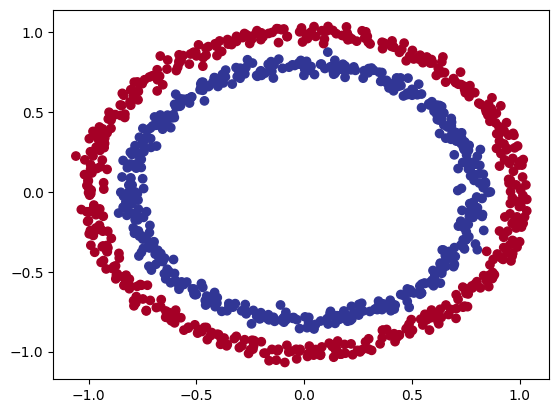

In [80]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],y=X[:,1],c=y,cmap=plt.cm.RdYlBu);

Always ask yourselves what shapes are my input and what shapes are my output

In [81]:
X.shape, y.shape

((1000, 2), (1000,))

In [82]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


This tells us the second dimension for X means it has 2 features (vector) where as y has a single feature (scalar)

We have two inputs for one output

**Turn data into tensors and create train and test split**

In [83]:
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [84]:
# Train and testing split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

#**2. Building a model**

In [85]:
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [86]:
# 1. Construct a model class that subclasses nn.Module
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    #2. Create 2 nn.Linear layer capable of handling X and y input and output shapes
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

  # 3. Define a forward method containing the forward pass computation
  def forward(self, x):
    # Return the output of layer_2, a single feature, the same shape as y
    return self.layer_2(self.layer_1(x)) #Computation goes through layer_1 first then the o/p of layer_1 goes through layer_2


model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [87]:
# Make predictions
untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[-0.1269],
        [-0.0967],
        [-0.1908],
        [-0.1089],
        [-0.1667],
        [-0.1484],
        [-0.0826],
        [-0.0946],
        [-0.1918],
        [-0.0944]], grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [88]:
# Create a Loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# create an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)


In [89]:
# Calculate accuracy (a classification metrics)

def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred))*100
  return acc

**3. Train Model**

In [90]:
torch.manual_seed(42)

epochs=100

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
for epoch in range(epochs):
  ### Training
  model_0.train()

  # 1. Forward pass
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # 2. calculate loss/accuracy
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

  # 3. Optimizer
  optimizer.zero_grad()

  # 4. Loss backwards
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  ## Testing
  model_0.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # 2. caculate loss/accuracy
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    if epoch%10==0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc: .2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69569, Accuracy:  50.00% | Test loss: 0.69739, Test acc: 50.00%
Epoch: 10 | Loss: 0.69544, Accuracy:  50.00% | Test loss: 0.69720, Test acc: 50.00%
Epoch: 20 | Loss: 0.69522, Accuracy:  50.00% | Test loss: 0.69703, Test acc: 50.00%
Epoch: 30 | Loss: 0.69501, Accuracy:  50.00% | Test loss: 0.69688, Test acc: 50.00%
Epoch: 40 | Loss: 0.69483, Accuracy:  50.00% | Test loss: 0.69675, Test acc: 50.00%
Epoch: 50 | Loss: 0.69467, Accuracy:  50.00% | Test loss: 0.69663, Test acc: 50.00%
Epoch: 60 | Loss: 0.69452, Accuracy:  50.00% | Test loss: 0.69653, Test acc: 50.00%
Epoch: 70 | Loss: 0.69438, Accuracy:  50.00% | Test loss: 0.69644, Test acc: 50.00%
Epoch: 80 | Loss: 0.69426, Accuracy:  50.00% | Test loss: 0.69635, Test acc: 50.00%
Epoch: 90 | Loss: 0.69415, Accuracy:  50.00% | Test loss: 0.69628, Test acc: 50.00%


In [91]:
# visualize

import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


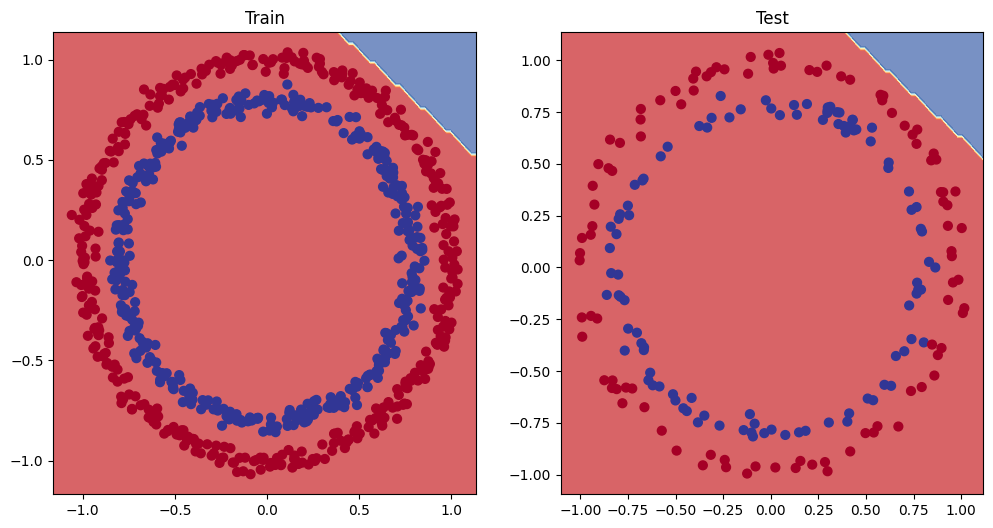

In [92]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

Few Changed Hyperparameters

In [93]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=2, out_features=10)
    self.layer2 = nn.Linear(in_features=10, out_features=10)
    self.layer3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    return self.layer3(self.layer2(self.layer1(x)))


model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
)

In [94]:
loss_fn = nn.BCEWithLogitsLoss() # Does not require sigmoid on input
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)

In [95]:
torch.manual_seed(42)

epochs = 1000 # Train for longer

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### Training
    # 1. Forward pass
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> predicition probabilities -> prediction labels

    # 2. Calculate loss/accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)

    # Print out what's happening every 10 epochs
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69396, Accuracy: 50.88% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 100 | Loss: 0.69305, Accuracy: 50.38% | Test loss: 0.69379, Test acc: 48.00%
Epoch: 200 | Loss: 0.69299, Accuracy: 51.12% | Test loss: 0.69437, Test acc: 46.00%
Epoch: 300 | Loss: 0.69298, Accuracy: 51.62% | Test loss: 0.69458, Test acc: 45.00%
Epoch: 400 | Loss: 0.69298, Accuracy: 51.12% | Test loss: 0.69465, Test acc: 46.00%
Epoch: 500 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69467, Test acc: 46.00%
Epoch: 600 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 700 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 800 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 900 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%


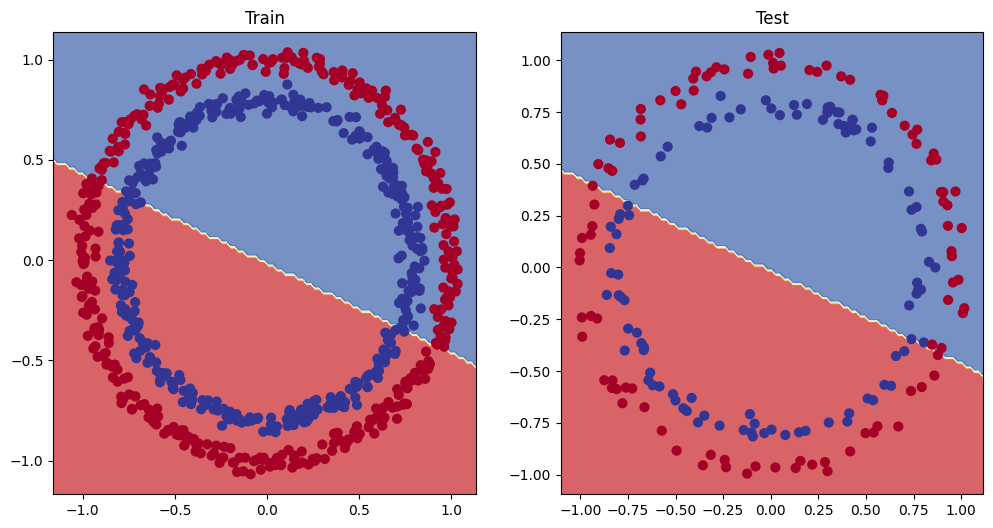

In [96]:

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

Still drawing a straight line between red and blue dots, even after adding extra hidden layer

##**6.The Missing piece: Non-linearity**

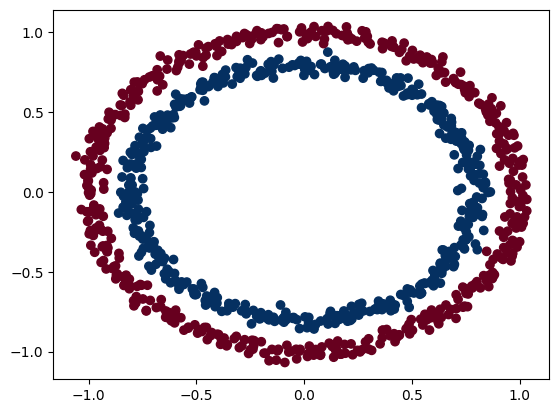

In [97]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples=1000,
    noise=0.03,
    random_state=42,
)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu);

In [98]:
# Convert to tensors and split into train and test sets
import torch
from sklearn.model_selection import train_test_split

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42
)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [99]:
# Build model with non-linear activation function
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=2, out_features=10)
    self.layer2 = nn.Linear(in_features=10, out_features=10)
    self.layer3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU() # <- add in ReLU activation function
    # can also put sigmoid in the model
    # this would mean you dont need to use it on the predictions
    # self.sigmoid = nn.sigmoid()

  def forward(self, x):
    # Interspace the ReLU activation function between layers
    return self.layer3(self.relu(self.layer2(self.layer1(x))))


model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [100]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(), lr=0.1)

In [101]:
# Fit the model
torch.manual_seed(42)
epochs = 1000

# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    # 1. Forward pass
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels

    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train) # BCEWithLogitsLoss calculates loss using logits
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_3.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model_3(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits)) # logits -> prediction probabilities -> prediction labels
      # 2. Calcuate loss and accuracy
      test_loss = loss_fn(test_logits, y_test)
      test_acc = accuracy_fn(y_true=y_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69833, Accuracy: 50.00% | Test Loss: 0.69863, Test Accuracy: 49.00%
Epoch: 100 | Loss: 0.69289, Accuracy: 50.88% | Test Loss: 0.69411, Test Accuracy: 47.00%
Epoch: 200 | Loss: 0.69015, Accuracy: 53.37% | Test Loss: 0.69141, Test Accuracy: 50.00%
Epoch: 300 | Loss: 0.68762, Accuracy: 56.62% | Test Loss: 0.68828, Test Accuracy: 55.00%
Epoch: 400 | Loss: 0.68469, Accuracy: 60.00% | Test Loss: 0.68469, Test Accuracy: 61.00%
Epoch: 500 | Loss: 0.67985, Accuracy: 56.00% | Test Loss: 0.67890, Test Accuracy: 60.50%
Epoch: 600 | Loss: 0.67280, Accuracy: 56.00% | Test Loss: 0.67176, Test Accuracy: 60.50%
Epoch: 700 | Loss: 0.66304, Accuracy: 64.50% | Test Loss: 0.66452, Test Accuracy: 65.00%
Epoch: 800 | Loss: 0.64710, Accuracy: 74.12% | Test Loss: 0.65300, Test Accuracy: 71.50%
Epoch: 900 | Loss: 0.62182, Accuracy: 81.62% | Test Loss: 0.63241, Test Accuracy: 78.00%


In [102]:
model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_preds[:10], y[:10]

(tensor([1., 1., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

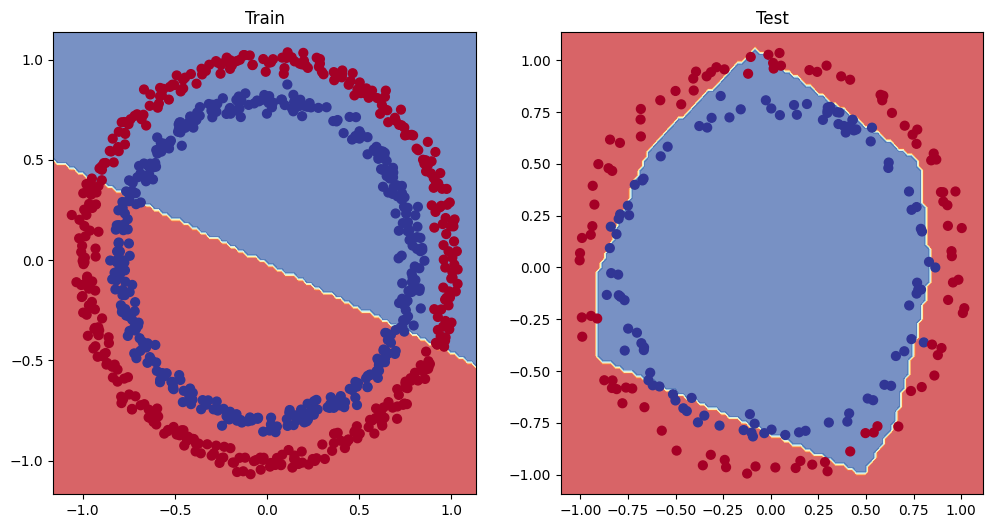

In [103]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

#**8. Putting things together by building a mult-class pytorch model**

tensor([[-8.9003e+00, -8.3375e+00, -7.0377e+00,  6.3382e+00],
        [-5.1935e+00, -5.4588e+00, -9.9976e+00,  7.9341e+00],
        [-3.1877e+00,  5.3785e+00,  2.2640e+00,  3.1138e+00],
        [-2.1194e+00,  1.0187e+01,  2.7845e+00, -7.5152e-03],
        [-5.3856e+00, -8.0153e+00, -1.0971e+01,  9.5755e+00]]) tensor([1, 1, 0, 0, 1])


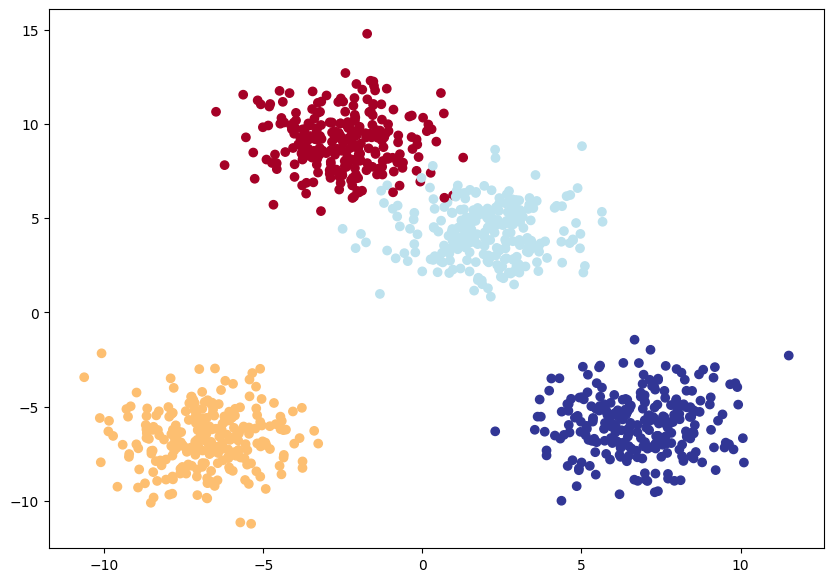

In [104]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

NUM_CLASSES=4
NUM_FEATURES=4
RANDOM_SEED =42

X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers = NUM_CLASSES,
                            cluster_std=1.5,
                            random_state=RANDOM_SEED)

# Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.long) # Changed to torch.long
print(X_blob[:5], y_blob[:5])

# splitting
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, test_size=0.2, random_state=RANDOM_SEED)

# Plot
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0], X_blob[:,1], c=y_blob, cmap=plt.cm.RdYlBu)

In [105]:
# Build model
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        """Initializes all required hyperparameters for a multi-class classification model.

        Args:
            input_features (int): Number of input features to the model.
            out_features (int): Number of output features of the model
              (how many classes there are).
            hidden_units (int): Number of hidden units between layers, default 8.
        """
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            # nn.ReLU(), # <- does our dataset require non-linear layers? (try uncommenting and see if the results change)
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            # nn.ReLU(), # <- does our dataset require non-linear layers? (try uncommenting and see if the results change)
            nn.Linear(in_features=hidden_units, out_features=output_features), # how many classes are there?
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

# Create an instance of BlobModel and send it to the target device
model_4 = BlobModel(input_features=NUM_FEATURES,
                    output_features=NUM_CLASSES,
                    hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [106]:
# Create loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_4.parameters(),
                            lr=0.1)

In [107]:
model_4(X_blob_train.to(device))[:5]

tensor([[-1.6804, -0.9000, -2.6877,  0.6348],
        [ 0.3873,  0.6991,  1.1377,  0.4386],
        [-1.9420, -1.3572, -2.4936,  0.4083],
        [-1.9307, -1.4162, -2.4989,  0.4134],
        [-0.9484, -0.1279, -1.4333,  1.0253]], grad_fn=<SliceBackward0>)

In [108]:
model_4(X_blob_train.to(device))[0].shape, NUM_CLASSES

(torch.Size([4]), 4)

In [109]:
# Make prediction logits with model
y_logits = model_4(X_blob_test.to(device))

# Perform softmax calculation on logits across dimension 1 to get prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-0.5460, -0.3909, -1.7360,  0.2696],
        [-1.3246, -0.4085, -2.1461,  0.9840],
        [-0.0488,  0.0817, -1.1949,  0.4843],
        [-2.3355, -1.7259, -2.9642,  0.3864],
        [-1.9810, -1.5116, -2.4391,  0.2996]], grad_fn=<SliceBackward0>)
tensor([[0.2113, 0.2467, 0.0643, 0.4777],
        [0.0714, 0.1785, 0.0314, 0.7186],
        [0.2403, 0.2738, 0.0764, 0.4095],
        [0.0538, 0.0990, 0.0287, 0.8185],
        [0.0768, 0.1229, 0.0486, 0.7517]], grad_fn=<SliceBackward0>)


In [110]:

# Sum the first sample output of the softmax activation function
torch.sum(y_pred_probs[0])

tensor(1., grad_fn=<SumBackward0>)

In [111]:
# Which class does the model think is *most* likely at the index 0 sample?
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))


tensor([0.2113, 0.2467, 0.0643, 0.4777], grad_fn=<SelectBackward0>)
tensor(3)


In [112]:
# Fit the model
torch.manual_seed(42)

# Set number of epochs
epochs = 100

# Put data to target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    ### Training
    model_4.train()

    # 1. Forward pass
    y_logits = model_4(X_blob_train) # model outputs raw logits
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # go from logits -> prediction probabilities -> prediction labels
    # print(y_logits)
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ## Testing
    model_4.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model_4(X_blob_test)
      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
      # 2. Calculate test loss and accuracy
      test_loss = loss_fn(test_logits, y_blob_test)
      test_acc = accuracy_fn(y_true=y_blob_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 2.23270, Acc: 0.75% | Test Loss: 1.01119, Test Acc: 54.50%
Epoch: 10 | Loss: 0.05815, Acc: 100.00% | Test Loss: 0.05046, Test Acc: 100.00%
Epoch: 20 | Loss: 0.02079, Acc: 100.00% | Test Loss: 0.01943, Test Acc: 100.00%
Epoch: 30 | Loss: 0.01209, Acc: 100.00% | Test Loss: 0.01146, Test Acc: 100.00%
Epoch: 40 | Loss: 0.00837, Acc: 100.00% | Test Loss: 0.00796, Test Acc: 100.00%
Epoch: 50 | Loss: 0.00634, Acc: 100.00% | Test Loss: 0.00603, Test Acc: 100.00%
Epoch: 60 | Loss: 0.00507, Acc: 100.00% | Test Loss: 0.00482, Test Acc: 100.00%
Epoch: 70 | Loss: 0.00421, Acc: 100.00% | Test Loss: 0.00399, Test Acc: 100.00%
Epoch: 80 | Loss: 0.00359, Acc: 100.00% | Test Loss: 0.00339, Test Acc: 100.00%
Epoch: 90 | Loss: 0.00312, Acc: 100.00% | Test Loss: 0.00294, Test Acc: 100.00%


In [113]:
# Make predictions
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)

# View the first 10 predictions
y_logits[:10]


tensor([[ 4.2998, -2.9268, -0.4561, -8.6790],
        [-1.7533, -2.6323,  6.1867, -6.7665],
        [ 5.9019, -4.9127,  0.2735, -8.9294],
        [-5.7566,  6.5653, -1.1306, -3.9563],
        [-5.4485,  6.8204, -1.8353, -2.2092],
        [-4.4737,  1.6980,  3.5752,  9.9206],
        [-0.5238, -3.5093,  5.9086, -7.1951],
        [ 3.8043, -2.2432, -0.7845, -6.0729],
        [-4.8078,  4.7772,  0.0907, -2.9662],
        [-3.7486,  4.9265, -1.3176, -4.5985]])

In [114]:
# Turn predicted logits in prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)

# Turn prediction probabilities into prediction labels
y_preds = y_pred_probs.argmax(dim=1)

# Compare first 10 model preds and test labels
print(f"Predictions: {y_preds[:10]}\nLabels: {y_blob_test[:10]}")
print(f"Test accuracy: {accuracy_fn(y_true=y_blob_test, y_pred=y_preds)}%")

Predictions: tensor([0, 2, 0, 1, 1, 3, 2, 0, 1, 1])
Labels: tensor([0, 2, 0, 1, 1, 3, 2, 0, 1, 1])
Test accuracy: 100.0%


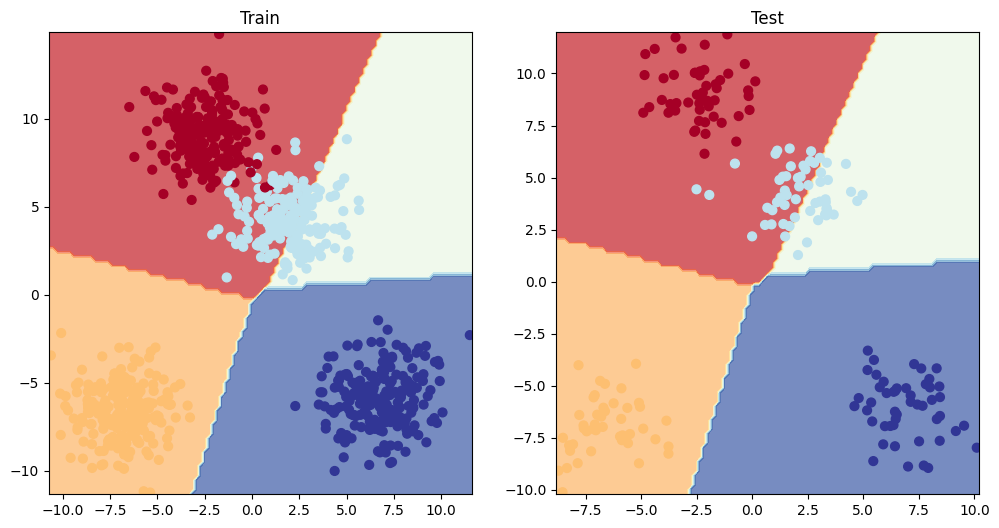

In [115]:
from torch import nn

# Create a wrapper model for plotting that pads the input
class BlobModelPlotter(nn.Module):
    def __init__(self, original_model, total_input_features=NUM_FEATURES):
        super().__init__()
        self.original_model = original_model
        self.total_input_features = total_input_features

    def forward(self, x):
        # Check if the input needs padding (i.e., it's a 2D meshgrid)
        if x.shape[1] < self.total_input_features:
            padding_needed = self.total_input_features - x.shape[1]
            # Pad with zeros for the remaining features
            padding = torch.zeros(x.shape[0], padding_needed, device=x.device, dtype=x.dtype)
            x_padded = torch.cat((x, padding), dim=1)
            return self.original_model(x_padded)
        else:
            # If input already has correct number of features, pass directly
            return self.original_model(x)

# Instantiate the plotter model
model_4_plotter = BlobModelPlotter(model_4).to(device)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4_plotter, X_blob_train, y_blob_train) # Use the plotter model
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4_plotter, X_blob_test, y_blob_test)   # Use the plotter model